<a href="https://colab.research.google.com/github/princeiiitk/House-Price-Prediction/blob/main/House_Price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project** : House Price pridiction using Regression based model our maine objective to build a model to pridict accurate house price or in other word the sales price of house by using explotory data analysis and apply feature engineering , end of model we evaluate the model to see how good our model

Step1 : Setup - Import Libraries and kaggle api

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
import os
sns.set_style('whitegrid')


Step 2: Data loading via kaggle API


In [ ]:
# Install the Kaggle library
!pip install -q kaggle

# Use Colab's file uploader
from google.colab import files
print("Please upload the kaggle.json file you downloaded from your Kaggle account.")
files.upload()

# Create a directory for the Kaggle API configuration
!mkdir -p ~/.kaggle
# Move the uploaded kaggle.json to the required directory
!cp kaggle.json ~/.kaggle/
# Set the correct permissions for the file
!chmod 600 ~/.kaggle/kaggle.json

print("\nKaggle API configured successfully.")

Please upload the kaggle.json file you downloaded from your Kaggle account.


Saving kaggle.json to kaggle (3).json

Kaggle API configured successfully.


In [ ]:
# Download the dataset from the 'house-prices-advanced-regression-techniques' competition
!kaggle competitions download -c house-prices-advanced-regression-techniques

# Unzip the downloaded files
!unzip -o house-prices-advanced-regression-techniques.zip

print("\nDataset downloaded and unzipped.")

house-prices-advanced-regression-techniques.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  house-prices-advanced-regression-techniques.zip
  inflating: data_description.txt    
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               

Dataset downloaded and unzipped.


In [ ]:
train_df=pd.read_csv('train.csv')
test_df=pd.read_csv('test.csv')
train_df.set_index('Id', inplace=True)
test_df.set_index('Id', inplace=True)
train_df.head(11)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900


SalePrice - the property's sale price in dollars. This is the target variable   that you're trying to predict.  
MSSubClass: The building class  
MSZoning: The general zoning classification  
LotFrontage: Linear feet of street connected to property  
LotArea: Lot size in square feet  
Street: Type of road access  
Alley: Type of alley access  
LotShape: General shape of property  
LandContour: Flatness of the property  
Utilities: Type of utilities available  
LotConfig: Lot configuration  
LandSlope: Slope of property  
Neighborhood: Physical locations within Ames city limits  
Condition1: Proximity to main road or railroad  
Condition2: Proximity to main road or railroad (if a second is present)  
BldgType: Type of dwelling  
HouseStyle: Style of dwelling  
OverallQual: Overall material and finish quality  
OverallCond: Overall condition rating  
YearBuilt: Original construction date  
YearRemodAdd: Remodel date  
RoofStyle: Type of roof  
RoofMatl: Roof material  
Exterior1st: Exterior covering on house  
Exterior2nd: Exterior covering on house (if more than one material)  
MasVnrType: Masonry veneer type  
MasVnrArea: Masonry veneer area in square feet  
ExterQual: Exterior material quality  
ExterCond: Present condition of the material on the exterior  
Foundation: Type of foundation  
BsmtQual: Height of the basement  
BsmtCond: General condition of the basement  
BsmtExposure: Walkout or garden level basement walls  
BsmtFinType1: Quality of basement finished area  
BsmtFinSF1: Type 1 finished square feet  
BsmtFinType2: Quality of second finished area (if present)  
BsmtFinSF2: Type 2 finished square feet  
BsmtUnfSF: Unfinished square feet of basement area  
TotalBsmtSF: Total square feet of basement area  
Heating: Type of heating  
HeatingQC: Heating quality and condition  
CentralAir: Central air conditioning  
Electrical: Electrical system  
1stFlrSF: First Floor square feet  
2ndFlrSF: Second floor square feet  
LowQualFinSF: Low quality finished square feet (all floors)  
GrLivArea: Above grade (ground) living area square feet  
BsmtFullBath: Basement full bathrooms  
BsmtHalfBath: Basement half bathrooms  
FullBath: Full bathrooms above grade  
HalfBath: Half baths above grade  
Bedroom: Number of bedrooms above basement level  
Kitchen: Number of kitchens  
KitchenQual: Kitchen quality  
TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)  
Functional: Home functionality rating  
Fireplaces: Number of fireplaces  
FireplaceQu: Fireplace quality  
GarageType: Garage location  
GarageYrBlt: Year garage was built  
GarageFinish: Interior finish of the garage  
GarageCars: Size of garage in car capacity  
GarageArea: Size of garage in square feet  
GarageQual: Garage quality  
GarageCond: Garage condition  
PavedDrive: Paved driveway  
WoodDeckSF: Wood deck area in square feet  
OpenPorchSF: Open porch area in square feet  
EnclosedPorch: Enclosed porch area in square feet  
3SsnPorch: Three season porch area in square feet  
ScreenPorch: Screen porch area in square feet  
PoolArea: Pool area in square feet  
PoolQC: Pool quality  
Fence: Fence quality  
MiscFeature: Miscellaneous feature not covered in other categories  
MiscVal: $Value of miscellaneous feature  
MoSold: Month Sold  
YrSold: Year Sold  
SaleType: Type of sale  
SaleCondition: Condition of sale  


Step 3:  EDA on the Target Variable (SalePrice)

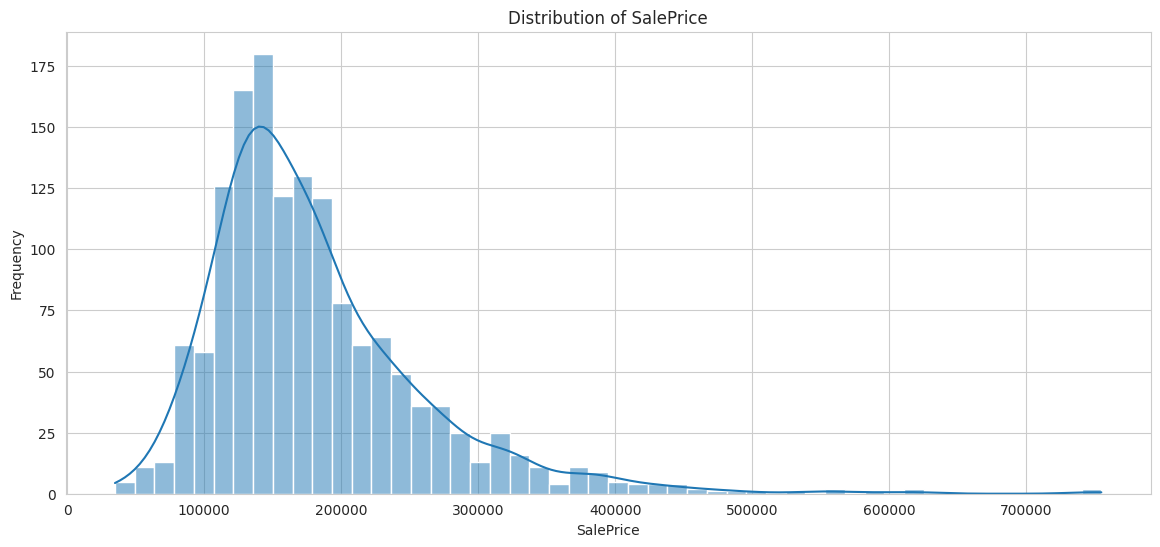

Skewness of SalePrice: 1.8828757597682129


In [ ]:
plt.figure(figsize=(14,6))
sns.histplot(train_df['SalePrice'],kde=True,bins=50)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()
print(f"Skewness of SalePrice: {train_df['SalePrice'].skew()}")

**Skewness and Log Transformation:**
The distribution of salesprice is +ve skewed this means there is long tail of very expensive house which -vely impact perfomance of some model specially Liear Regressio

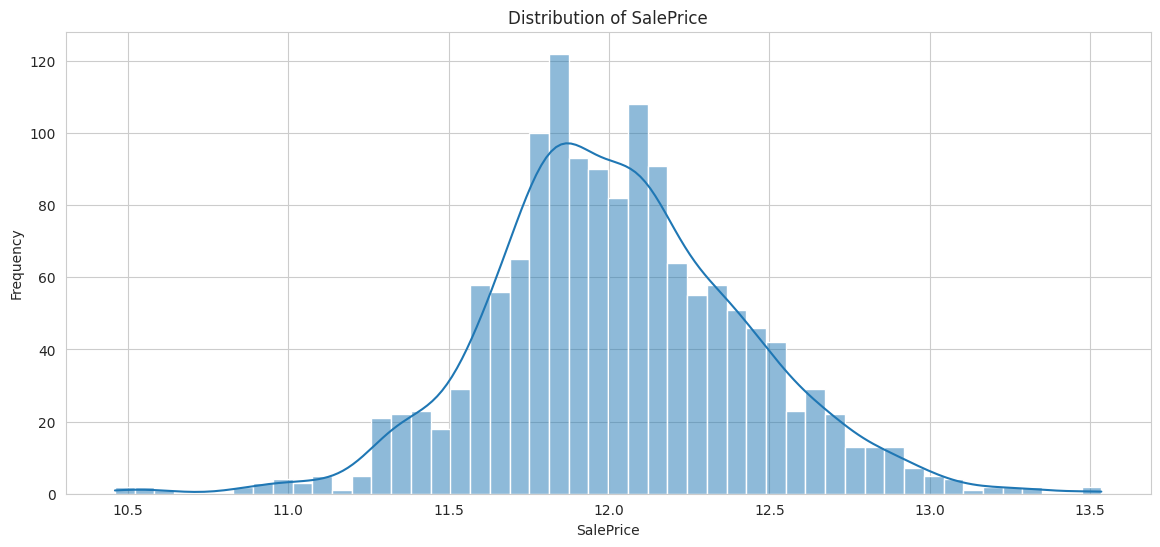

In [ ]:
train_df['SalePrice']=np.log1p(train_df['SalePrice'])
plt.figure(figsize=(14,6))
sns.histplot(train_df['SalePrice'],kde=True,bins=50)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()

Insights: After log transformation the distribution is much closer to normal distribution that means we apply Linear Regression with skewness is closed to 0. we will build the model to pridict the log pf price and convert to the original price

Step 4: EDA on Feature Variables

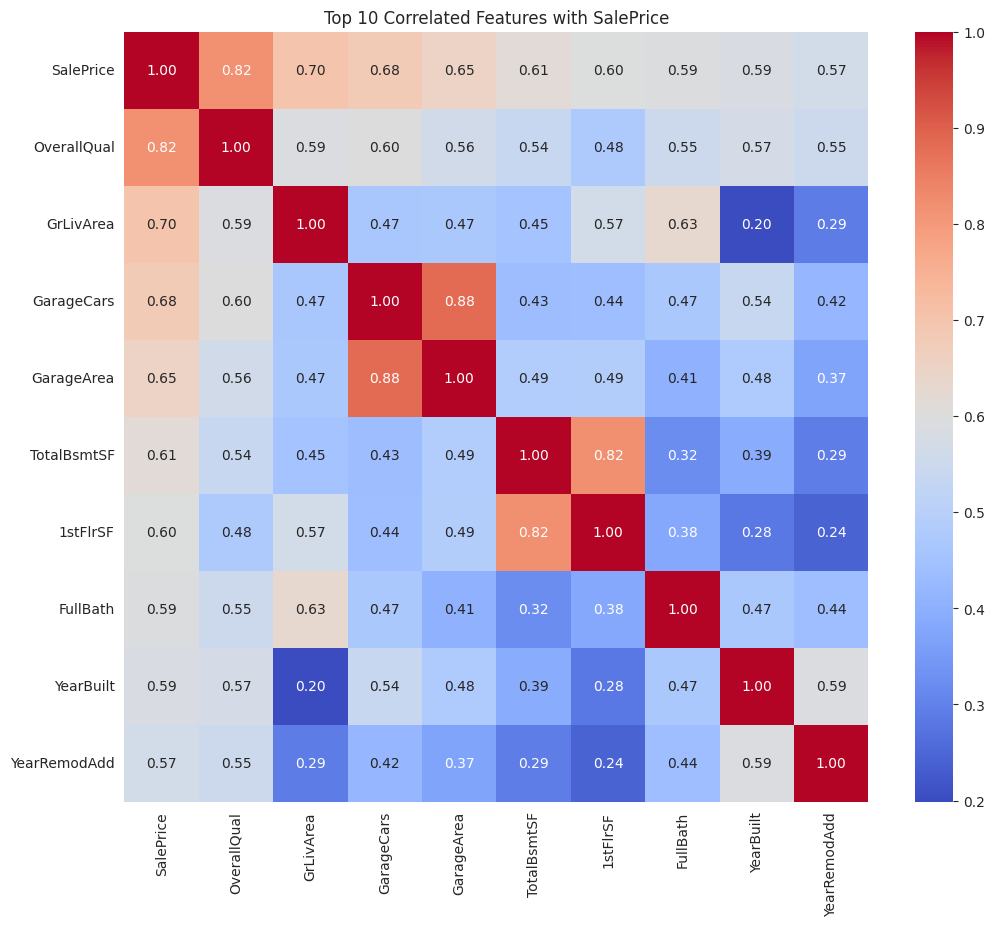

In [ ]:
#finf the top 10 feature most correlated with sales price
corrmat=train_df.corr(numeric_only=True)
top_corr_features=corrmat.nlargest(10,'SalePrice')['SalePrice'].index
top_corr_matrix=train_df[top_corr_features].corr()

plt.figure(figsize=(12,10))
sns.heatmap(top_corr_matrix,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Top 10 Correlated Features with SalePrice')
plt.show()

Insight: The heatmap shows that OverallQual (Overall Quality), GrLivArea (Above Ground Living Area), and GarageCars/GarageArea are the most positively correlated features with SalePrice. This makes intuitive sense—better quality, larger houses with bigger garages tend to be more expensive.

Step 5: Data Preprocessing & Feature Engineering
This is the most intensive part of the project. We will handle missing values, create new features, and encode categorical variables to prepare the data for modeling.

In [ ]:
#combin train and test data for consistent preprocessing
all_data=pd.concat((train_df.loc[:,:'SaleCondition'],test_df.loc[:,:'SaleCondition']))
print(f"Combine data shape :{all_data.shape}")

Combine data shape :(2919, 79)


Combined data shape: (2919, 79)
Combining the data this way ensures that any preprocessing steps (like handling missing values or encoding categorical features) are applied consistently across both the training and testing datasets, preventing data leakage and potential issues later in the modeling process.

5.1 Handling Missing Values

In [ ]:
#find missing values in the current all data
missing_data = all_data.isnull().sum().sort_values(ascending=False)
missing_data=missing_data[missing_data>0]
missing_data

,0
PoolQC,2909
MiscFeature,2814
Alley,2721
Fence,2348
MasVnrType,1766
FireplaceQu,1420
LotFrontage,486
GarageCond,159
GarageFinish,159
GarageYrBlt,159


In [ ]:
col=list(all_data.columns)
numeric_cols_to_impute_zero=[]
for i in col:
  if all_data[i].mode()[0] == 0 :
    numeric_cols_to_impute_zero.append(i)
print(numeric_cols_to_impute_zero)



['MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '2ndFlrSF', 'LowQualFinSF', 'BsmtFullBath', 'BsmtHalfBath', 'HalfBath', 'Fireplaces', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal']


In [ ]:
# Impute numerical features with 0
for col in numeric_cols_to_impute_zero:
  if col in all_data.columns:
    all_data[col]=all_data[col].fillna(0)

In [ ]:
all_data[numeric_cols_to_impute_zero].isnull().sum()

,0
MasVnrArea,0
BsmtFinSF1,0
BsmtFinSF2,0
BsmtUnfSF,0
TotalBsmtSF,0
2ndFlrSF,0
LowQualFinSF,0
BsmtFullBath,0
BsmtHalfBath,0
HalfBath,0


In [ ]:
all_data['LotFrontage'].value_counts()


,count
LotFrontage,
60.0,276
80.0,137
70.0,133
50.0,117
75.0,105
...,...
155.0,1
126.0,1
200.0,1


In [ ]:
#impute LotFrontage with median of the neighborhood
t1=all_data['LotFrontage'].value_counts()
t2=all_data['Neighborhood'].value_counts()
if 'LotFrontage' in all_data.columns and all_data['LotFrontage'].isnull().any():
  all_data['LotFrontage']=all_data.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
# t3.get_group('NAmes')
all_data['LotFrontage'].isnull().sum()

np.int64(0)

all_data.groupby('Neighborhood'): This groups the DataFrame by the Neighborhood column. The assumption here is that houses in the same neighborhood tend to have similar LotFrontage values.
.transform(lambda x: x.fillna(x.median())): This is the core imputation step. For each neighborhood group (x represents the LotFrontage Series for that group), it calculates the median of the existing LotFrontage values in that group (x.median()) and then fills the missing values (x.fillna(...)) within that same group with that calculated median. The transform function ensures that the result has the same index as the original DataFrame, allowing it to be assigned back to the LotFrontage column.

In [ ]:
# all_data['Alley'].value_counts()
all_data['Alley'].isnull().sum()

np.int64(2721)

In [ ]:
all_data['Electrical'].isnull().sum()

np.int64(1)

In [ ]:
coldtype=all_data.dtypes
col=all_data.columns
cat_col=[]
for i in col:
  if all_data[i].dtypes=='object':
    cat_col.append(i)
print(cat_col)

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [ ]:
all_data[cat_col].isnull().sum().sort_values(ascending=False)

,0
PoolQC,2909
MiscFeature,2814
Alley,2721
Fence,2348
MasVnrType,1766
FireplaceQu,1420
GarageCond,159
GarageQual,159
GarageFinish,159
GarageType,157


In [ ]:
missing = all_data[cat_col].isnull().sum().sort_values(ascending=False)

missinglessthan5 = list(missing[(missing < 5) & (missing != 0)].index)
missinggreaterthan5 = list(missing[(missing > 5) & (missing != 0)].index)
missinggreaterthan5

['PoolQC',
 'MiscFeature',
 'Alley',
 'Fence',
 'MasVnrType',
 'FireplaceQu',
 'GarageCond',
 'GarageQual',
 'GarageFinish',
 'GarageType',
 'BsmtCond',
 'BsmtExposure',
 'BsmtQual',
 'BsmtFinType2',
 'BsmtFinType1']

In [ ]:
for i in missinglessthan5:
  if i in all_data.columns:
    all_data[i]=all_data[i].fillna(all_data[i].mode()[0])

In [ ]:
for i in missinggreaterthan5:
  if i in all_data.columns:
    all_data[i]=all_data[i].fillna('None')

In [ ]:
all_data[cat_col].isnull().sum().sort_values(ascending=False)

,0
MSZoning,0
Street,0
Alley,0
LotShape,0
LandContour,0
Utilities,0
LotConfig,0
LandSlope,0
Neighborhood,0
Condition1,0


In [ ]:
all_data.isnull().sum().sort_values(ascending=False)

,0
GarageYrBlt,159
GarageCars,1
MSSubClass,0
LotArea,0
Street,0
...,...
MiscVal,0
MoSold,0
YrSold,0
SaleType,0


In [ ]:
all_data['GarageCars'].isnull().sum()

np.int64(1)

In [ ]:
all_data['GarageYrBlt'].isnull().sum()

np.int64(159)

In [ ]:
all_data['GarageCars']=all_data['GarageCars'].fillna(0)



In [ ]:
all_data['GarageCars'].isnull().sum()

np.int64(0)

In [ ]:
#based on the remaining missing value (GarageYrBlt), impute the remaining numerical feature
# GarageYrBlt can be imputed with 0 (assuming 0 means no garage, consistent with GarageArea/Cars=0)
all_data['GarageYrBlt']=all_data['GarageYrBlt'].fillna(0)

In [ ]:
print("\nMissing values after all imputation:", all_data.isnull().sum())


Missing values after all imputation: MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
                ..
MiscVal          0
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
Length: 79, dtype: int64


5.2 Feature Engineering

In [ ]:
#Create a total squar footage feature
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
# Create a total bathrooms feature
all_data['TotalBath'] = (all_data['FullBath'] + (0.5 * all_data['HalfBath']) +
                         all_data['BsmtFullBath'] + (0.5 * all_data['BsmtHalfBath']))

# Create a feature for age of the house at sale
all_data['Age'] = all_data['YrSold'] - all_data['YearBuilt']

5.3 Categorical Encoding

In [ ]:
# Convert any remaining object columns to category type for one-hot encoding
cat_col = all_data.select_dtypes(include=['object']).columns
all_data=pd.get_dummies(all_data,columns=cat_col,drop_first=True)


Step 6: Model Building & Training

In [ ]:
#Separate the preprocessed data back into training and testing
X=all_data[:len(train_df)]
y=train_df['SalePrice'] #SalePrice was already log-trasformed and is only in train_df
X_test_final=all_data[len(train_df):]

#Split the training data for validation
X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.isnull().sum().sort_values(ascending=False)

,0
SaleCondition_Partial,0
MSSubClass,0
LotFrontage,0
LotArea,0
OverallQual,0
...,...
BsmtUnfSF,0
BsmtFinSF2,0
BsmtFinSF1,0
MasVnrArea,0


Theoretical Concept : Feature Scaleing

Many models especially linear model and distace - based algoriths, perform better when numerical feature are on a similar scale

In [ ]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_val_scaled=scaler.transform(X_val)
X_test_final_scaled=scaler.transform(X_test_final)


6.1 Model 1: Linear Regression (Baseline)

In [ ]:
lr=LinearRegression()
lr.fit(X_train_scaled,y_train)
y_pred_lr=lr.predict(X_val_scaled)

Step 7: Model Evaluation

In [ ]:
def evaluate_model(y_true, y_pred,model_name):
  rmse=np.sqrt(mean_squared_error(y_true,y_pred))
  mae=mean_absolute_error(y_true,y_pred)
  r2=r2_score(y_true,y_pred)
  print(f"--- {model_name} Performance ---")
  print(f"RMSE: {rmse:.4f}")
  print(f"MAE:  {mae:.4f}")
  print(f"R-squared: {r2:.4f}\n")
evaluate_model(y_val, y_pred_lr, "Linear Regression")

--- Linear Regression Performance ---
RMSE: 0.1734
MAE:  0.0960
R-squared: 0.8389



In [ ]:
from xgboost import XGBRegressor
model2=XGBRegressor(n_estimators=1000,learning_rate=0.05,n_jobs=4)
